# Progetto Part 1: Analisi Esplorativa del Dataset

Questo notebook implementa l'analisi esplorativa del dataset di **fingerprint spoofing detection**.

## Obiettivo
Identificare immagini di impronte digitali genuine (True, label 1) rispetto a quelle contraffatte (False, label 0) utilizzando un dataset 6-dimensionale estratto da feature di alto livello.

## Dataset
- **File**: `trainData.txt`
- **Formato**: CSV con 6 feature + 1 label per ogni campione
- **Classi**: 
  - Classe 0 (False): Impronte false/contraffatte
  - Classe 1 (True): Impronte genuine

## 1. Import delle Librerie

Importiamo le librerie necessarie per l'analisi e la visualizzazione.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Caricamento del Dataset

Carichiamo i dati e li organizziamo:
- **D**: Matrice delle feature (6 × n_samples) - ogni riga è una feature, ogni colonna è un campione
- **L**: Vettore delle etichette (n_samples,) - 0 per False, 1 per True

La trasposizione `.T` serve perché vogliamo le feature sulle righe (formato standard per ML).

In [2]:
dataset = np.loadtxt('../trainData.txt', delimiter=',')
D=dataset[:,:6].T
L=dataset[:,6]

labels={
    1:"True",
    0:"False"
}

D,L

(array([[ 1.85284048, -0.21530775,  0.04653456, ..., -0.06393955,
          1.06665359, -0.47186462],
        [-0.16436898,  1.63665974, -1.16487257, ..., -0.92205024,
          3.27717415, -0.37118987],
        [ 1.09839078, -0.61831145,  0.04392191, ...,  1.65445602,
         -0.53087884, -1.04041218],
        [-0.93073689,  0.99002204, -0.41369086, ..., -1.527528  ,
          1.42338924, -0.253746  ],
        [-1.0193342 ,  0.38670252, -1.08847926, ...,  1.87609599,
         -1.11381038, -0.02120134],
        [ 1.16696309,  1.15926273, -1.37988988, ...,  0.75929015,
         -0.15047129, -1.4376229 ]], shape=(6, 6000)),
 array([1., 0., 1., ..., 1., 0., 0.], shape=(6000,)))

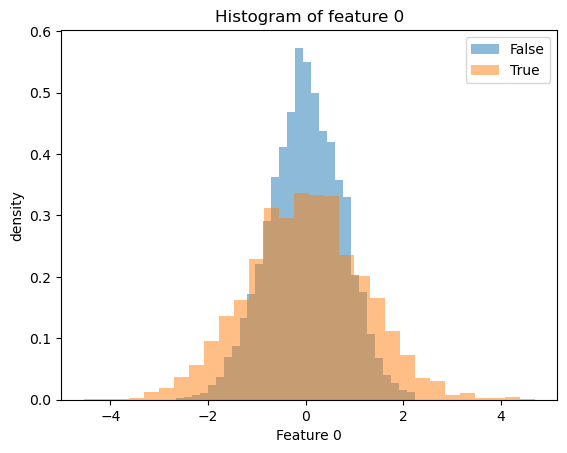

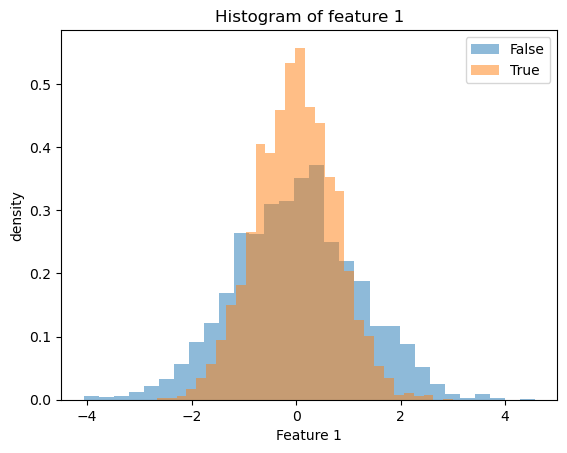

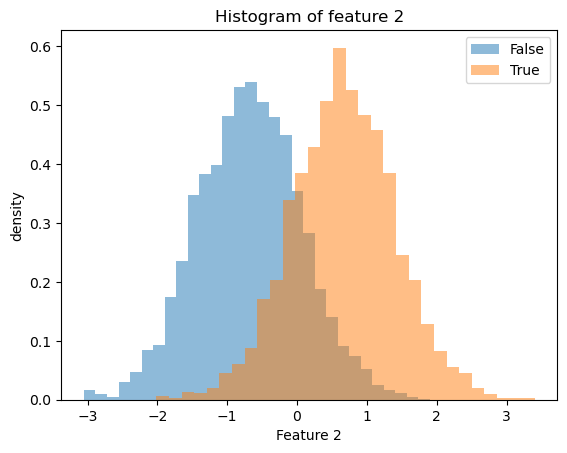

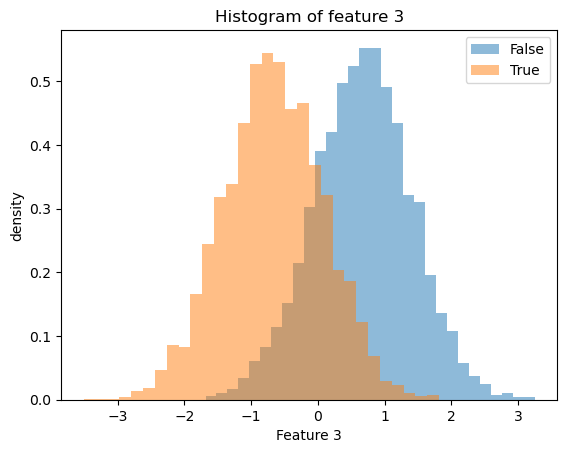

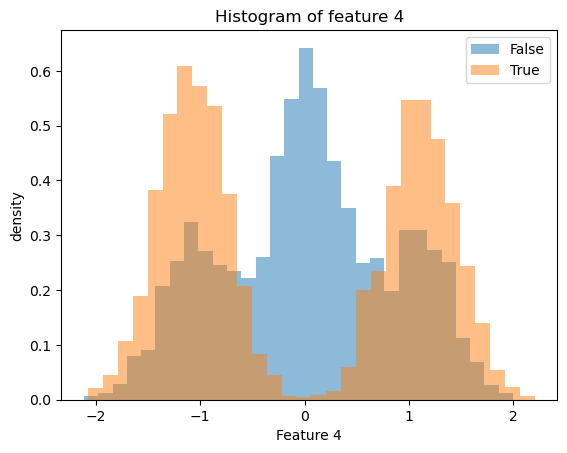

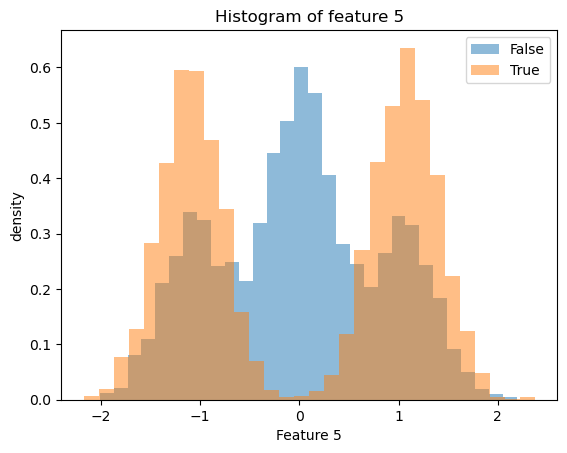

In [3]:
def getHist(D,L,classes):
    n_features = D.shape[0]  # numero effettivo di feature
    for i in range(n_features):
        plt.figure()
        plt.ylabel("density")
        plt.xlabel(f"Feature {i}")
        for cnt in range(2):
            mask= L==cnt
            # D[:, mask] estrae tutti i campioni di quella classe
            # [i, :] estrae solo i valori della i-esima feature per quei campioni
            feature_data = D[:, mask][i, :]
            plt.hist(feature_data, bins=30, density=True, alpha=0.5, label=f"{classes[cnt]}")
        
        plt.legend()  # Add legend after plotting all classes
        plt.title(f"Histogram of feature {i}")
        plt.show()  # Display the histogram
        
getHist(D,L,labels)


## 3. Istogrammi Normalizzati delle Feature

### Analisi Univariata

Gli istogrammi normalizzati (con `density=True`) mostrano la **distribuzione di probabilità** di ogni singola feature per entrambe le classi.

**Cosa osservare:**
- **Sovrapposizione**: Quanto le distribuzioni delle due classi si sovrappongono
- **Medie**: Se le due classi hanno valori centrali diversi
- **Varianze**: Se una classe è più dispersa dell'altra
- **Mode**: Numero di "picchi" (unimodale vs bimodale)

**Risultati attesi:**
- Features 0, 1: Forte sovrapposizione, medie simili, varianze diverse
- Features 2, 3: Medie molto diverse (~1.3 di distanza), buona separazione
- Features 4, 5: Classe True bimodale (2 cluster), classe False unimodale

In [4]:
# # Salva gli istogrammi delle feature originali
# def saveHist(D, L, classes, prefix="original"):
#     for i in range(6):
#         plt.figure()
#         plt.ylabel("density")
#         plt.xlabel(f"Feature {i}")
#         for cnt in range(2):
#             mask = L == cnt
#             feature_data = D[:, mask][i, :]
#             plt.hist(feature_data, bins=30, density=True, alpha=0.5, label=f"{classes[cnt]}")
#         
#         plt.legend()
#         plt.title(f"Histogram of feature {i}")
#         plt.tight_layout()
#         plt.savefig(f'../images/{prefix}_histogram_feature_{i}.png', dpi=150, bbox_inches='tight')
#         plt.close()
#     print(f"Salvati {6} istogrammi con prefisso '{prefix}'")
#
# saveHist(D, L, labels, "original")

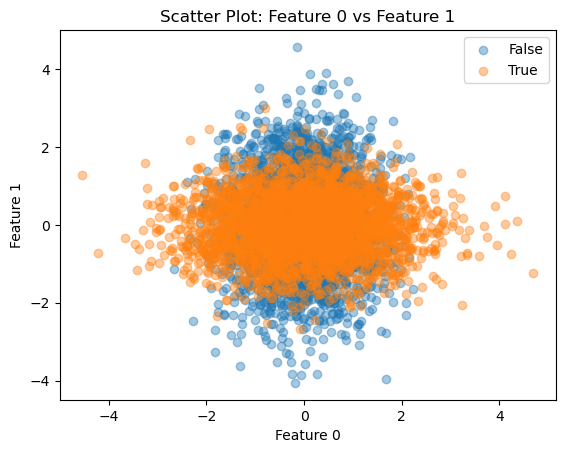

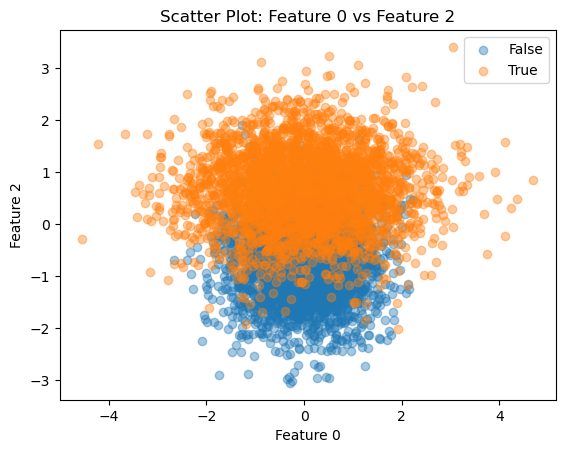

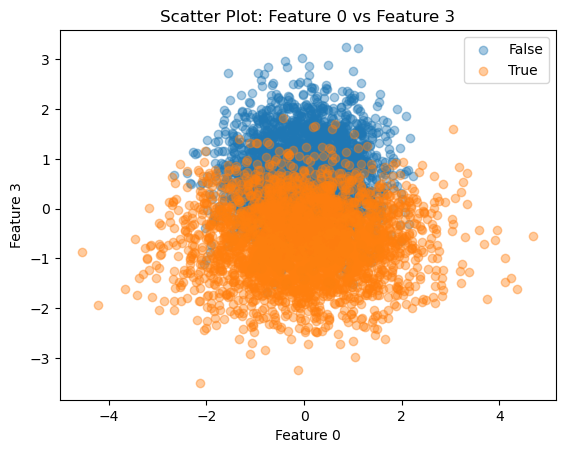

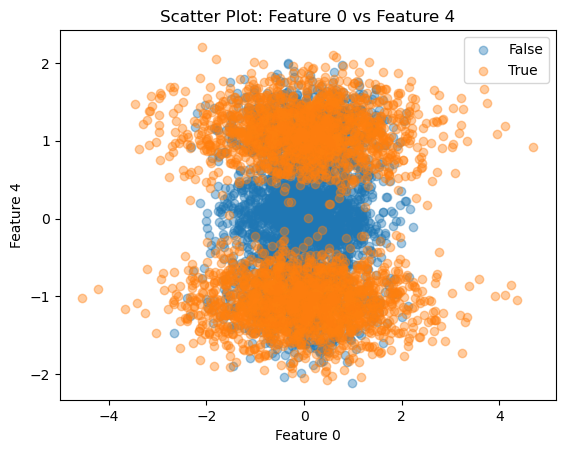

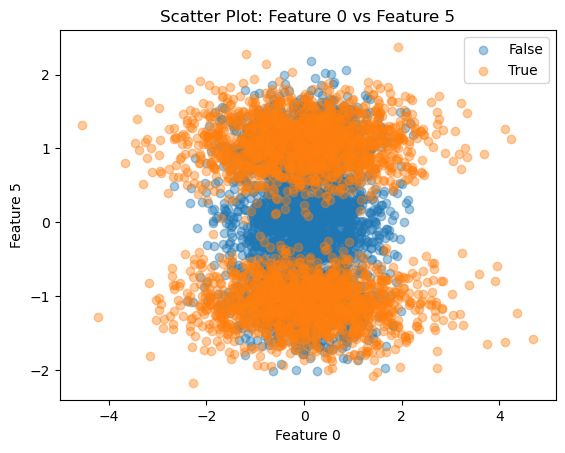

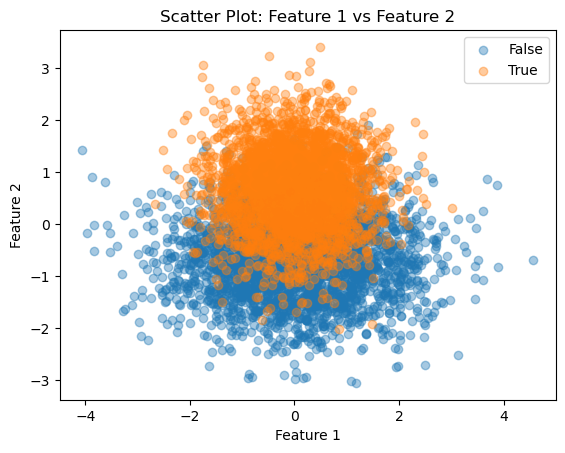

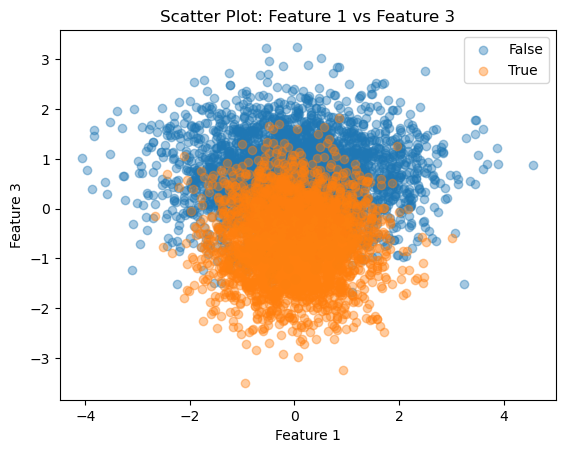

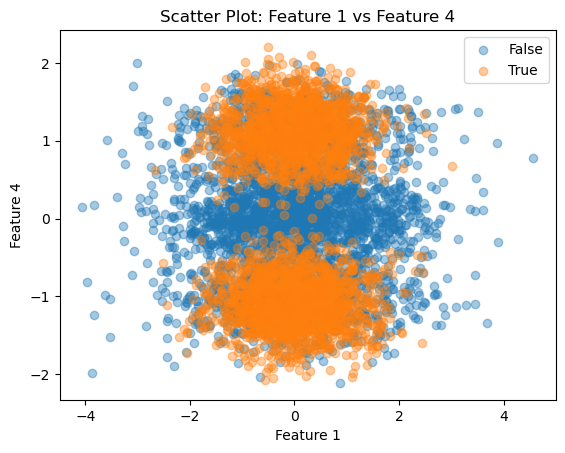

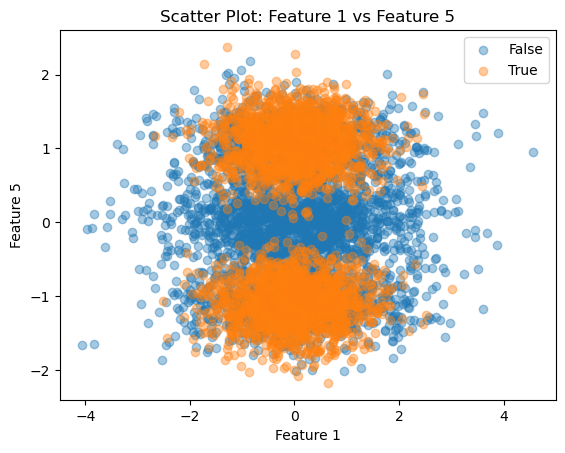

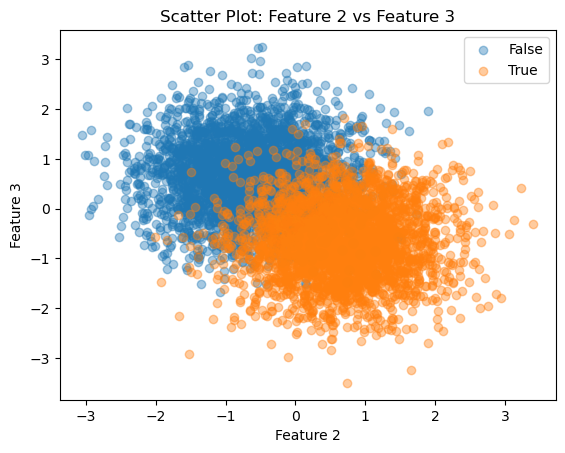

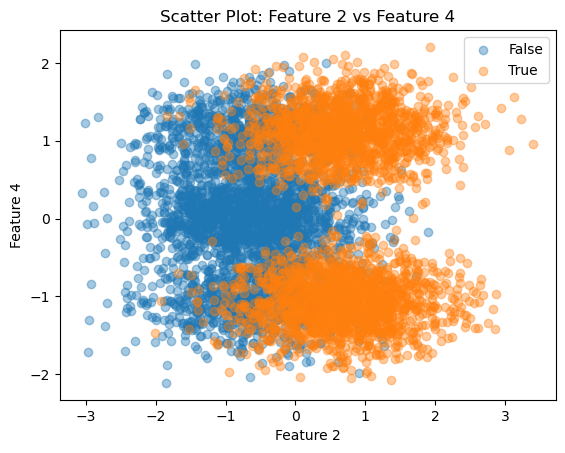

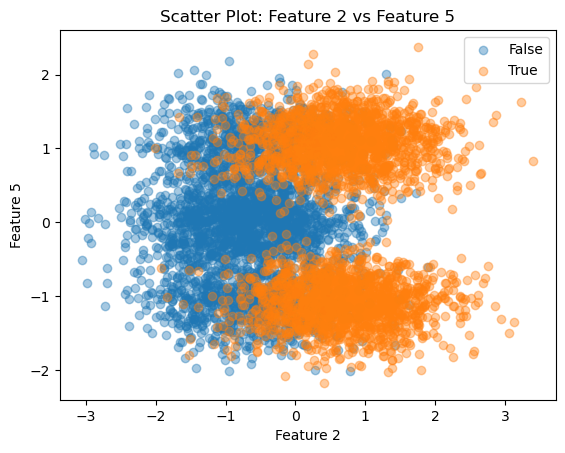

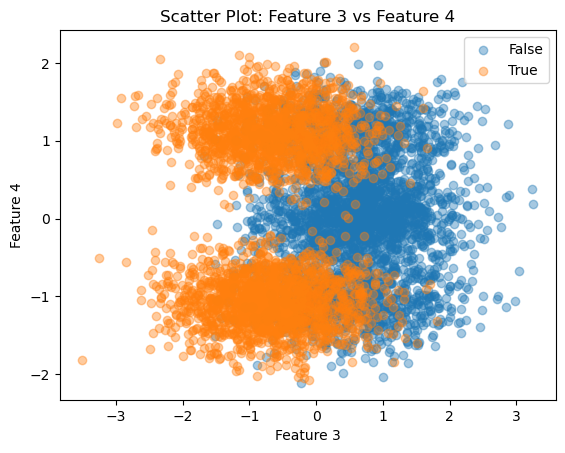

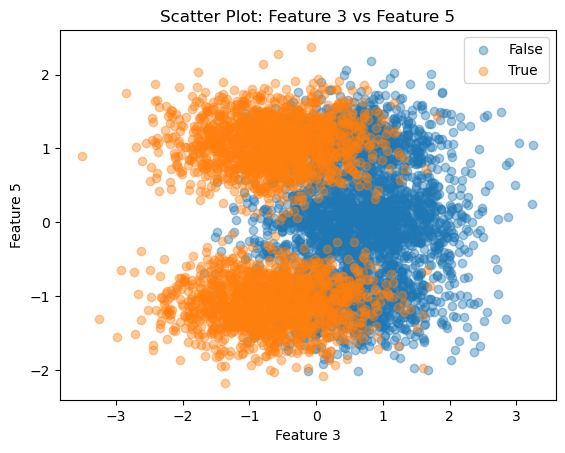

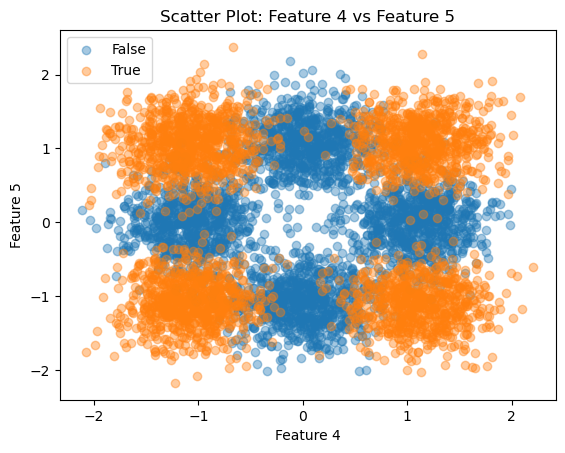

In [5]:
def getScatters(D,classes):
    for i in range(6):
        for j in range(i + 1, 6):
            plt.figure()
            plt.title(f"Scatter Plot: Feature {i} vs Feature {j}")
            plt.xlabel(f"Feature {i}")
            plt.ylabel(f"Feature {j}")
            
            for cnt in range(2):
                mask= L==cnt
                D0=D[:,mask]
                name=classes[cnt]
                plt.scatter(D0[i,:],D0[j,:],alpha=0.4, label=name)
                
            plt.legend()
            plt.show()    

getScatters(D,labels)
                

## 4. Scatter Plot a Coppie

### Analisi Bivariata

Gli scatter plot mostrano la relazione tra **coppie di feature** e rivelano:
- **Correlazioni**: Feature che variano insieme
- **Cluster**: Gruppi distinti di campioni all'interno delle classi
- **Separabilità**: Quanto le classi sono distinguibili nello spazio 2D

**Cosa cercare:**
- Feature 4 vs 5: La classe True mostra **2 cluster distinti** (struttura bimodale)
- Feature 2 vs 3: Buona separazione lineare tra le classi
- Feature 0 vs 1: Le classi si sovrappongono ma con orientamenti diversi

**Importante**: Vengono generati 15 scatter plot (tutte le coppie possibili tra 6 feature).

In [6]:
# # Salva alcuni scatter plot rappresentativi
# def saveScatters(D, L, classes, feature_pairs, prefix="original"):
#     for i, j in feature_pairs:
#         plt.figure(figsize=(8, 6))
#         plt.title(f"Scatter Plot: Feature {i} vs Feature {j}")
#         plt.xlabel(f"Feature {i}")
#         plt.ylabel(f"Feature {j}")
#         
#         for cnt in range(2):
#             mask = L == cnt
#             D0 = D[:, mask]
#             name = classes[cnt]
#             plt.scatter(D0[i, :], D0[j, :], alpha=0.4, label=name)
#         
#         plt.legend()
#         plt.tight_layout()
#         plt.savefig(f'../images/{prefix}_scatter_f{i}_vs_f{j}.png', dpi=150, bbox_inches='tight')
#         plt.close()
#     print(f"Salvati {len(feature_pairs)} scatter plot con prefisso '{prefix}'")
#
# # Salva scatter plot per coppie significative
# representative_pairs = [(0, 1), (2, 3), (4, 5), (0, 2), (1, 3)]
# saveScatters(D, L, labels, representative_pairs, "original")

## 5. Statistiche Descrittive: Medie e Covarianze

### Funzioni di Utilità
- **`getMu(D)`**: Calcola il vettore delle medie per ogni feature
- **`getRow()` / `getCol()`**: Reshape vettori per operazioni matriciali
- **`getC(D)`**: Calcola la matrice di covarianza (6×6)

### Calcolo delle Statistiche

Calcoliamo separatamente per:
1. **Globale** (tutto il dataset): `mu`, `C`
2. **Classe False** (L==0): `mu0`, `C0`
3. **Classe True** (L==1): `mu1`, `C1`

### Cosa Rivelano le Statistiche

**Vettore delle medie (6 valori):**
- Confronta `mu0` vs `mu1` per vedere quali feature hanno medie diverse tra classi
- Features 2 e 3 dovrebbero mostrare le differenze più marcate

**Matrice di covarianza (6×6):**
- Diagonale: varianze delle singole feature
- Fuori diagonale: correlazioni tra coppie di feature
- Confronta `C0` vs `C1` per vedere se le classi hanno strutture di correlazione diverse

**Risultati attesi:**
- Feature 0: varianza False < True (circa 0.57 vs 1.43)
- Feature 1: varianza False > True (circa 1.42 vs 0.58)
- Features 2-3: varianze simili tra le classi (~0.55)
- Features 4-5: classe True con varianza maggiore (struttura bimodale)

In [7]:
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

def getRow(vet):
    return vet.reshape((1, vet.size))
def getCol(vet):
     return vet.reshape((vet.size, 1))

def getC(D):
    mu=getMu(D)
    mu=getCol(mu)
    Dc=D-mu
    return (Dc @ Dc.T)/Dc.shape[1]


D0=D[:,L==0]
D1=D[:,L==1]

mu0=getMu(D0)
mu1=getMu(D1)
mu=getMu(D)

C0=getC(D0)
C1=getC(D1)
C=getC(D)

print(f"Le medie sono, media globale {mu}, media per i falsi {mu0} e media per i veri {mu1}")
print(f"Le covarianze sono, covarianza globale {C}, covarianza per i falsi {C0} e covarianza per i veri {C1}")

Le medie sono, media globale [ 0.00170711  0.00503903 -0.00560753  0.00109537 -0.00700025  0.00910515], media per i falsi [ 0.00287744  0.01869316 -0.68094016  0.6708362   0.02795697 -0.0058274 ] e media per i veri [ 5.44547838e-04 -8.52437392e-03  6.65237846e-01 -6.64195349e-01
 -4.17251858e-02  2.39384879e-02]
Le covarianze sono, covarianza globale [[ 1.00134304e+00  5.16755817e-03  1.76746375e-03  1.45268757e-02
   1.00066790e-02 -1.29591239e-02]
 [ 5.16755817e-03  9.98352699e-01 -1.58354137e-02 -4.40650280e-04
  -4.01307317e-03 -8.17687100e-04]
 [ 1.76746375e-03 -1.58354137e-02  1.00248180e+00 -4.37060381e-01
  -2.68600594e-02  6.34388503e-03]
 [ 1.45268757e-02 -4.40650280e-04 -4.37060381e-01  9.90293894e-01
   2.53357434e-02  8.26930215e-03]
 [ 1.00066790e-02 -4.01307317e-03 -2.68600594e-02  2.53357434e-02
   1.00119747e+00  8.75793087e-04]
 [-1.29591239e-02 -8.17687100e-04  6.34388503e-03  8.26930215e-03
   8.75793087e-04  9.97223742e-01]], covarianza per i falsi [[ 5.69581054e-0